In [1]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from pathlib import Path
import shutil, subprocess

In [2]:
def evaluate_binary_mask(pred_mask, gt_mask, ignore_gt_values=(50, 85, 170)):
    # Convert to single channel if needed
    if pred_mask.ndim == 3:
        pred_mask = cv2.cvtColor(pred_mask, cv2.COLOR_BGR2GRAY)
    if gt_mask.ndim == 3:
        gt_mask = cv2.cvtColor(gt_mask, cv2.COLOR_BGR2GRAY)

    # Build validity mask: ignore uncertain GT labels
    valid = np.ones_like(gt_mask, dtype=bool)
    for v in ignore_gt_values:
        valid &= (gt_mask != v)

    # Binarize prediction and GT
    pred_fg = (pred_mask == 255)
    gt_fg = (gt_mask == 255)

    # Apply valid-mask filtering
    pred_fg = pred_fg[valid]
    gt_fg = gt_fg[valid]

    tp = int(np.sum(pred_fg & gt_fg))
    fp = int(np.sum(pred_fg & (~gt_fg)))
    tn = int(np.sum((~pred_fg) & (~gt_fg)))
    fn = int(np.sum((~pred_fg) & gt_fg))

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

    return {
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

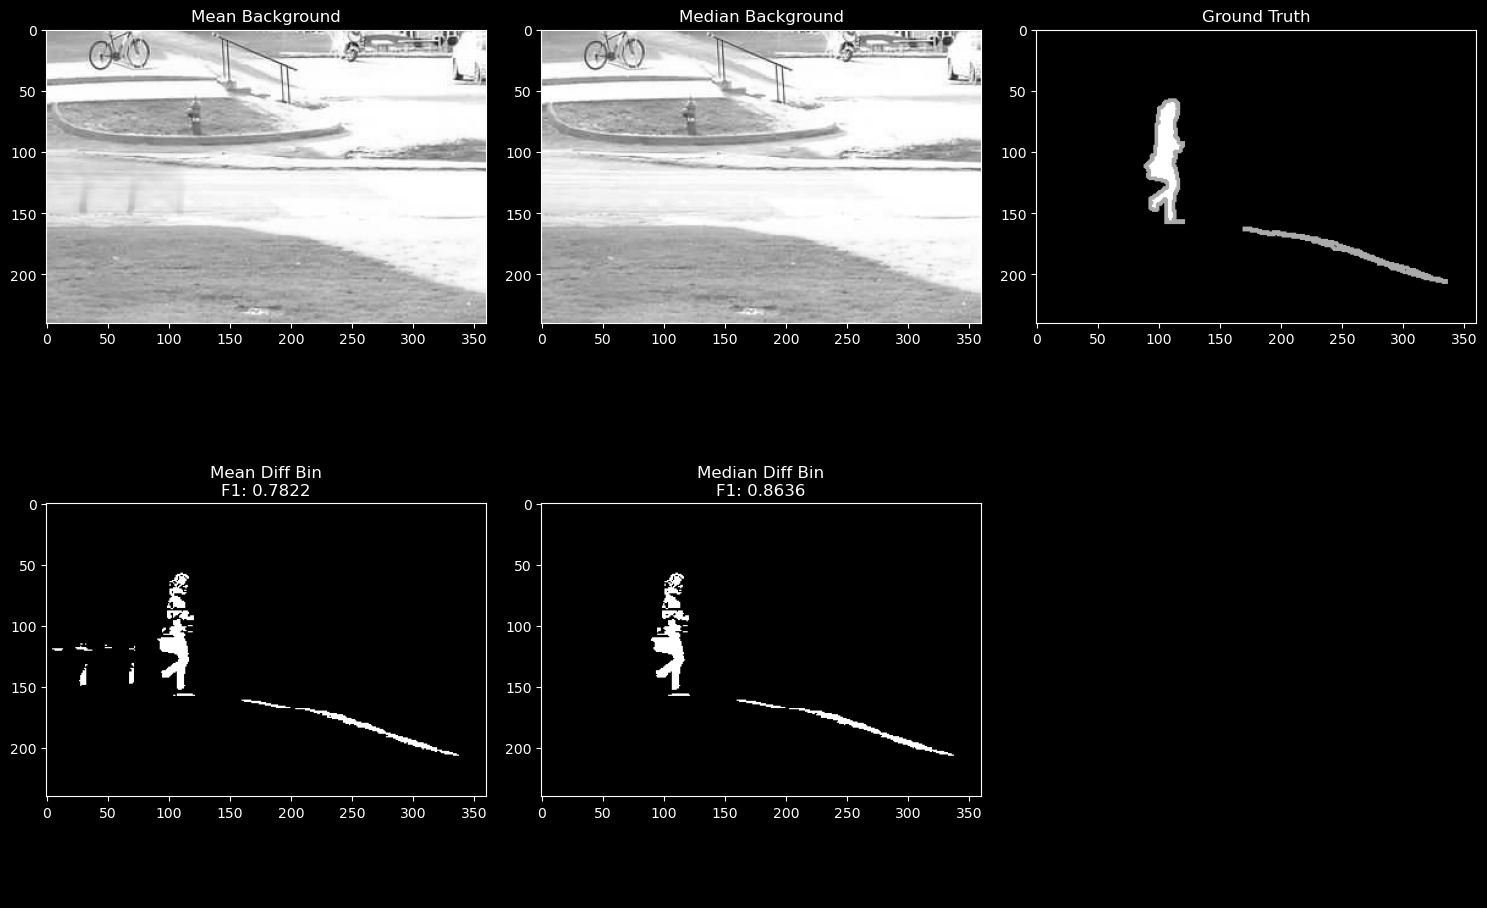

Mean Background Results:
F1 Score: 0.7822
Precision: 0.8029
Recall: 0.7626

Median Background Results:
F1 Score: 0.8636
Precision: 0.9655
Recall: 0.7812


In [19]:
data_path = Path('../lab2/data')
pedestrian_path = data_path / 'pedestrian'
office_path = data_path / 'office'
analysed_frame = 350

def get_frame(path, i):
    return cv2.imread(str(path / f'in{i:06d}.jpg'))

def get_gt(path, i):
    return cv2.imread(str(path / f'gt{i:06d}.png'))


def run_mean_median_background(path, analysed_frame, n=60, max_frames=1000, threshold=30):
    frames_dir = path / 'input'
    gt_path = path / 'groundtruth'

    first_frame = get_frame(path=frames_dir, i=1)
    if first_frame is None:
        raise ValueError(f'No starting frame found in: {frames_dir}')

    x, y, _ = first_frame.shape
    buf = np.zeros((x, y, n), dtype=np.uint8)
    i_n = 0

    mean_bg, median_bg = None, None
    mean_diff_bin, median_diff_bin = None, None

    for i in range(1, max_frames):
        frame = get_frame(path=frames_dir, i=i)
        if frame is None:
            break

        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        buf[:, :, i_n] = frame_gray
        i_n = (i_n + 1) % n

        if i == analysed_frame:
            mean_bg = np.mean(buf, axis=2).astype(np.uint8)
            median_bg = np.median(buf, axis=2).astype(np.uint8)

            mean_diff = cv2.absdiff(frame_gray, mean_bg)
            _, mean_diff_bin = cv2.threshold(mean_diff, threshold, 255, cv2.THRESH_BINARY)

            median_diff = cv2.absdiff(frame_gray, median_bg)
            _, median_diff_bin = cv2.threshold(median_diff, threshold, 255, cv2.THRESH_BINARY)
            break

    if mean_bg is None or median_bg is None:
        raise ValueError(f'Analyzed frame {analysed_frame} was not processed.')

    gt_frame = get_gt(path=gt_path, i=analysed_frame)
    if gt_frame is None:
        raise ValueError(f'Ground truth frame not found: {analysed_frame}')

    mean_results = evaluate_binary_mask(mean_diff_bin, gt_frame)
    median_results = evaluate_binary_mask(median_diff_bin, gt_frame)

    f, ax = plt.subplots(2, 3, figsize=(15, 10))
    ax[0, 0].imshow(mean_bg, cmap='gray')
    ax[0, 0].set_title('Mean Background')
    ax[0, 1].imshow(median_bg, cmap='gray')
    ax[0, 1].set_title('Median Background')
    ax[0, 2].imshow(gt_frame, cmap='gray')
    ax[0, 2].set_title('Ground Truth')
    ax[1, 0].imshow(mean_diff_bin, cmap='gray')
    ax[1, 0].set_title(f'Mean Diff Bin\nF1: {mean_results["f1"]:.4f}')
    ax[1, 1].imshow(median_diff_bin, cmap='gray')
    ax[1, 1].set_title(f'Median Diff Bin\nF1: {median_results["f1"]:.4f}')
    ax[1, 2].axis('off')
    plt.tight_layout()
    plt.show()

    print('Mean Background Results:')
    print(f"F1 Score: {mean_results['f1']:.4f}")
    print(f"Precision: {mean_results['precision']:.4f}")
    print(f"Recall: {mean_results['recall']:.4f}")
    print('\nMedian Background Results:')
    print(f"F1 Score: {median_results['f1']:.4f}")
    print(f"Precision: {median_results['precision']:.4f}")
    print(f"Recall: {median_results['recall']:.4f}")

    return {
        'mean_bg': mean_bg,
        'median_bg': median_bg,
        'mean_diff_bin': mean_diff_bin,
        'median_diff_bin': median_diff_bin,
        'mean_results': mean_results,
        'median_results': median_results,
    }

results = run_mean_median_background(path=pedestrian_path, analysed_frame=analysed_frame)

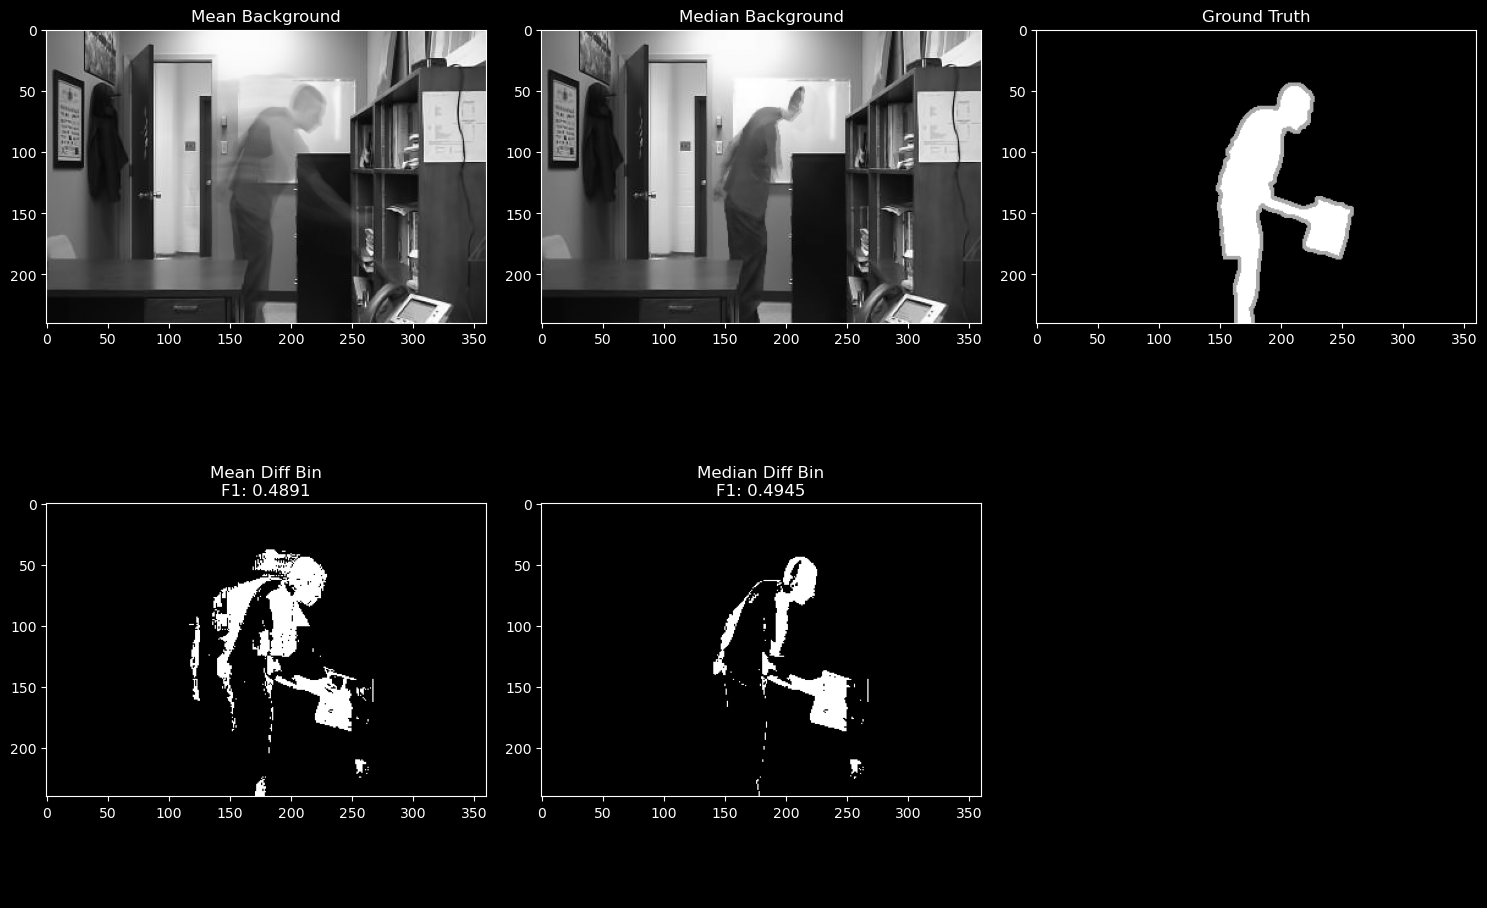

Mean Background Results:
F1 Score: 0.4891
Precision: 0.5784
Recall: 0.4237

Median Background Results:
F1 Score: 0.4945
Precision: 0.8754
Recall: 0.3445


In [20]:
results = run_mean_median_background(path=office_path, analysed_frame=700)

Wyniki sigma-delta (alpha=0.01):
Srednia (EMA) F1 avg: 0.5382, F1@350: 0.8586
Mediana (SD)  F1 avg: 0.5380, F1@350: 0.8497
Czas: 1.573s, ~635.0 FPS


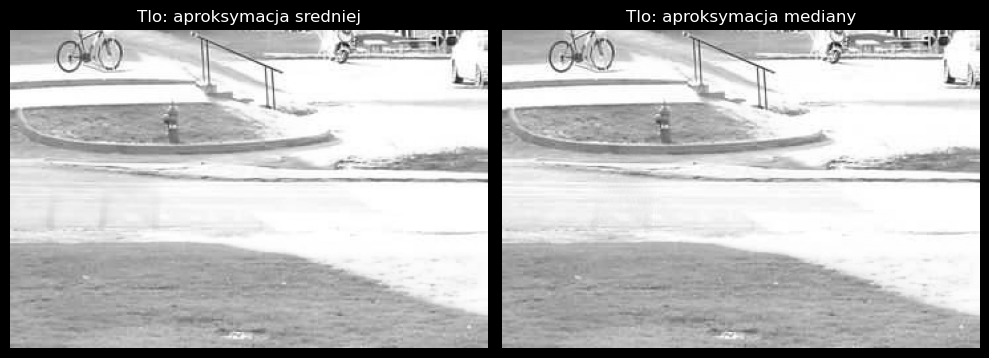


Eksperyment alpha:
alpha | mean_f1_avg | mean_f1@350 | median_f1_avg | czas[s] | FPS
0.001 | 0.5133      | 0.8394     | 0.5380       | 1.244  | 802.8
0.005 | 0.5387      | 0.8616     | 0.5380       | 1.095  | 912.4
0.01  | 0.5382      | 0.8586     | 0.5380       | 1.107  | 902.7
0.02  | 0.5158      | 0.8382     | 0.5380       | 1.120  | 891.8
0.05  | 0.4174      | 0.6540     | 0.5380       | 1.171  | 853.4


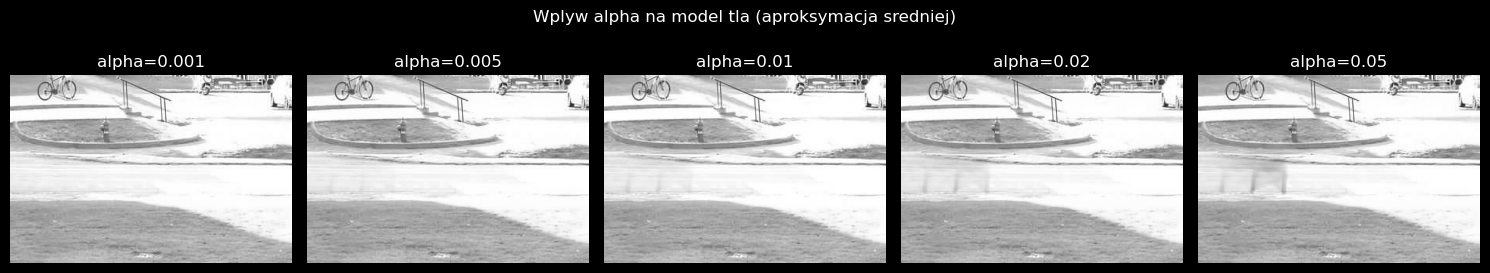

In [21]:
import time

def sigma_delta_eval(path=pedestrian_path, alpha=0.01, threshold=30, start_idx=1, end_idx=1000, sample_frame=350):
    frames_dir = path / 'input'
    gt_path = path / 'groundtruth'
    first = get_frame(path=frames_dir, i=start_idx)
    if first is None:
        raise ValueError(f"Brak ramki startowej: {start_idx}")

    first_gray = cv2.cvtColor(first, cv2.COLOR_BGR2GRAY)
    bg_mean = first_gray.astype(np.float32)
    bg_median = first_gray.astype(np.int16)

    f1_mean_at_sample = None
    f1_median_at_sample = None
    bg_mean_sample = None
    bg_median_sample = None

    sum_f1_mean, sum_f1_median = 0.0, 0.0
    count_valid = 0

    t0 = time.perf_counter()
    for i in range(start_idx + 1, end_idx + 1):
        frame = get_frame(path=frames_dir, i=i)
        gt = get_gt(path=gt_path, i=i)
        if frame is None or gt is None:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        bg_mean = alpha * gray + (1.0 - alpha) * bg_mean
        bg_median += (gray > bg_median).astype(np.int16)
        bg_median -= (gray < bg_median).astype(np.int16)

        mean_bg_u8 = np.clip(bg_mean, 0, 255).astype(np.uint8)
        median_bg_u8 = np.clip(bg_median, 0, 255).astype(np.uint8)

        mean_diff = cv2.absdiff(gray, mean_bg_u8)
        _, mean_bin = cv2.threshold(mean_diff, threshold, 255, cv2.THRESH_BINARY)
        median_diff = cv2.absdiff(gray, median_bg_u8)
        _, median_bin = cv2.threshold(median_diff, threshold, 255, cv2.THRESH_BINARY)

        mean_metrics = evaluate_binary_mask(mean_bin, gt)
        median_metrics = evaluate_binary_mask(median_bin, gt)

        sum_f1_mean += mean_metrics["f1"]
        sum_f1_median += median_metrics["f1"]
        count_valid += 1

        if i == sample_frame:
            f1_mean_at_sample = mean_metrics["f1"]
            f1_median_at_sample = median_metrics["f1"]
            bg_mean_sample = mean_bg_u8.copy()
            bg_median_sample = median_bg_u8.copy()

    elapsed = time.perf_counter() - t0
    if count_valid == 0:
        raise RuntimeError("Nie przetworzono zadnej ramki z GT.")

    return {
        "alpha": alpha,
        "frames_processed": count_valid,
        "mean_f1_avg": sum_f1_mean / count_valid,
        "median_f1_avg": sum_f1_median / count_valid,
        "mean_f1_sample": f1_mean_at_sample,
        "median_f1_sample": f1_median_at_sample,
        "elapsed_s": elapsed,
        "fps": count_valid / elapsed if elapsed > 0 else np.nan,
        "bg_mean_sample": bg_mean_sample,
        "bg_median_sample": bg_median_sample,
    }

base = sigma_delta_eval(alpha=0.01, threshold=30, start_idx=1, end_idx=1000, sample_frame=350)
print("Wyniki sigma-delta (alpha=0.01):")
print(f"Srednia (EMA) F1 avg: {base['mean_f1_avg']:.4f}, F1@350: {base['mean_f1_sample']:.4f}")
print(f"Mediana (SD)  F1 avg: {base['median_f1_avg']:.4f}, F1@350: {base['median_f1_sample']:.4f}")
print(f"Czas: {base['elapsed_s']:.3f}s, ~{base['fps']:.1f} FPS")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(base['bg_mean_sample'], cmap='gray')
ax[0].set_title('Tlo: aproksymacja sredniej')
ax[0].axis('off')
ax[1].imshow(base['bg_median_sample'], cmap='gray')
ax[1].set_title('Tlo: aproksymacja mediany')
ax[1].axis('off')
plt.tight_layout()
plt.show()

alphas = [0.001, 0.005, 0.01, 0.02, 0.05]
rows = []
mean_models = []
for a in alphas:
    r = sigma_delta_eval(alpha=a, threshold=30, start_idx=1, end_idx=1000, sample_frame=350)
    rows.append(r)
    mean_models.append((a, r['bg_mean_sample']))

print("\nEksperyment alpha:")
print("alpha | mean_f1_avg | mean_f1@350 | median_f1_avg | czas[s] | FPS")
for r in rows:
    print(
        f"{r['alpha']:<5} | {r['mean_f1_avg']:.4f}      | {r['mean_f1_sample']:.4f}     | "
        f"{r['median_f1_avg']:.4f}       | {r['elapsed_s']:.3f}  | {r['fps']:.1f}"
    )

fig, ax = plt.subplots(1, len(mean_models), figsize=(3 * len(mean_models), 3))
for k, (a, model) in enumerate(mean_models):
    ax[k].imshow(model, cmap='gray')
    ax[k].set_title(f'alpha={a}')
    ax[k].axis('off')
plt.suptitle('Wplyw alpha na model tla (aproksymacja sredniej)')
plt.tight_layout()
plt.show()

Porownanie mediany (liberalna vs konserwatywna):
Liberalna     F1 avg: 0.5380
Konserwatywna F1 avg: 0.5383
Liberalna     F1@350: 0.8497
Konserwatywna F1@350: 0.8545


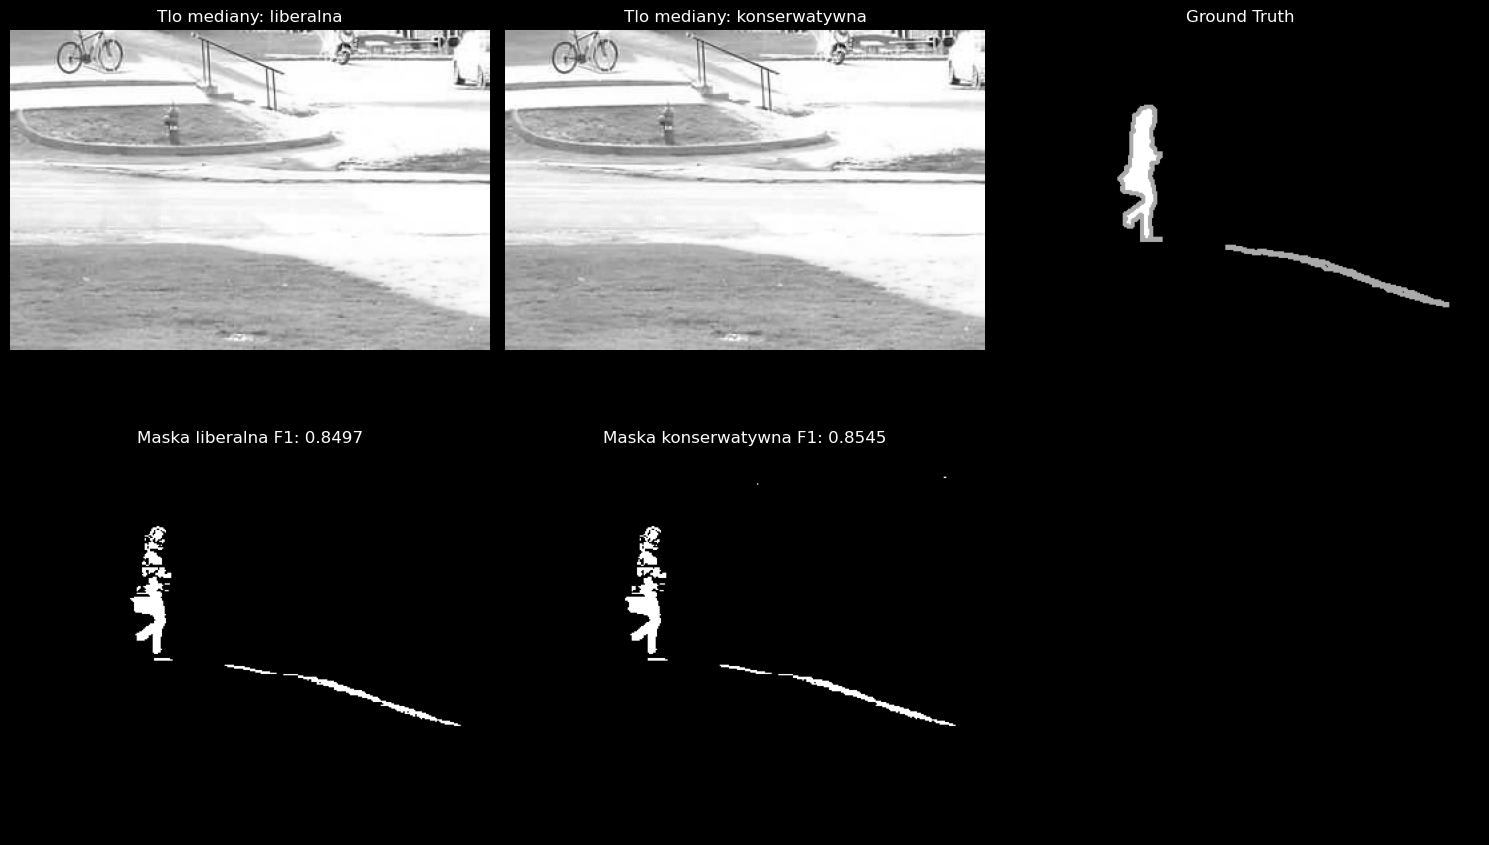

In [24]:
def compare_liberal_vs_conservative_median(
    path=pedestrian_path, threshold=30, start_idx=1, end_idx=1000, sample_frame=350
 ):
    frames_dir = path / 'input'
    gt_path = path / 'groundtruth'

    first = get_frame(path=frames_dir, i=start_idx)
    if first is None:
        raise ValueError(f'Brak ramki startowej: {start_idx}')

    bg_median_liberal = cv2.cvtColor(first, cv2.COLOR_BGR2GRAY).astype(np.int16)
    bg_median_conservative = bg_median_liberal.copy()
    prev_fg_mask = np.zeros_like(bg_median_liberal, dtype=bool)

    sum_f1_liberal, sum_f1_conservative = 0.0, 0.0
    count_valid = 0

    sample = {
        'bg_liberal': None,
        'bg_conservative': None,
        'bin_liberal': None,
        'bin_conservative': None,
        'gt': None,
        'f1_liberal': None,
        'f1_conservative': None,
    }

    for i in range(start_idx + 1, end_idx + 1):
        frame = get_frame(path=frames_dir, i=i)
        gt = get_gt(path=gt_path, i=i)
        if frame is None or gt is None:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Liberalna aktualizacja: aktualizujemy cale tlo.
        bg_median_liberal += (gray > bg_median_liberal).astype(np.int16)
        bg_median_liberal -= (gray < bg_median_liberal).astype(np.int16)

        # Konserwatywna aktualizacja: nie aktualizujemy pikseli,
        # ktore byly zaklasyfikowane jako obiekt w poprzedniej ramce.
        delta = (gray > bg_median_conservative).astype(np.int16) - (
            gray < bg_median_conservative
        ).astype(np.int16)
        bg_mask = ~prev_fg_mask
        bg_median_conservative[bg_mask] += delta[bg_mask]

        bg_liberal_u8 = np.clip(bg_median_liberal, 0, 255).astype(np.uint8)
        bg_conservative_u8 = np.clip(bg_median_conservative, 0, 255).astype(np.uint8)

        diff_liberal = cv2.absdiff(gray, bg_liberal_u8)
        _, bin_liberal = cv2.threshold(diff_liberal, threshold, 255, cv2.THRESH_BINARY)

        diff_conservative = cv2.absdiff(gray, bg_conservative_u8)
        _, bin_conservative = cv2.threshold(
            diff_conservative, threshold, 255, cv2.THRESH_BINARY
        )

        metrics_liberal = evaluate_binary_mask(bin_liberal, gt)
        metrics_conservative = evaluate_binary_mask(bin_conservative, gt)

        sum_f1_liberal += metrics_liberal['f1']
        sum_f1_conservative += metrics_conservative['f1']
        count_valid += 1

        if i == sample_frame:
            sample['bg_liberal'] = bg_liberal_u8.copy()
            sample['bg_conservative'] = bg_conservative_u8.copy()
            sample['bin_liberal'] = bin_liberal.copy()
            sample['bin_conservative'] = bin_conservative.copy()
            sample['gt'] = gt.copy()
            sample['f1_liberal'] = metrics_liberal['f1']
            sample['f1_conservative'] = metrics_conservative['f1']

        prev_fg_mask = bin_conservative == 255

    if count_valid == 0:
        raise RuntimeError('Nie przetworzono zadnej ramki z GT.')

    out = {
        'frames_processed': count_valid,
        'f1_avg_liberal': sum_f1_liberal / count_valid,
        'f1_avg_conservative': sum_f1_conservative / count_valid,
        'sample': sample,
    }
    return out

cmp = compare_liberal_vs_conservative_median(
    path=pedestrian_path, threshold=30, start_idx=1, end_idx=1000, sample_frame=350
)

print('Porownanie mediany (liberalna vs konserwatywna):')
print(f"Liberalna     F1 avg: {cmp['f1_avg_liberal']:.4f}")
print(f"Konserwatywna F1 avg: {cmp['f1_avg_conservative']:.4f}")
if cmp['sample']['f1_liberal'] is not None:
    print(f"Liberalna     F1@350: {cmp['sample']['f1_liberal']:.4f}")
    print(f"Konserwatywna F1@350: {cmp['sample']['f1_conservative']:.4f}")

if cmp['sample']['bg_liberal'] is not None:
    fig, ax = plt.subplots(2, 3, figsize=(15, 9))
    ax[0, 0].imshow(cmp['sample']['bg_liberal'], cmap='gray')
    ax[0, 0].set_title('Tlo mediany: liberalna')
    ax[0, 0].axis('off')

    ax[0, 1].imshow(cmp['sample']['bg_conservative'], cmap='gray')
    ax[0, 1].set_title('Tlo mediany: konserwatywna')
    ax[0, 1].axis('off')

    ax[0, 2].imshow(cmp['sample']['gt'], cmap='gray')
    ax[0, 2].set_title('Ground Truth')
    ax[0, 2].axis('off')

    ax[1, 0].imshow(cmp['sample']['bin_liberal'], cmap='gray')
    ax[1, 0].set_title(
        f"Maska liberalna F1: {cmp['sample']['f1_liberal']:.4f}"
    )
    ax[1, 0].axis('off')

    ax[1, 1].imshow(cmp['sample']['bin_conservative'], cmap='gray')
    ax[1, 1].set_title(
        f"Maska konserwatywna F1: {cmp['sample']['f1_conservative']:.4f}"
    )
    ax[1, 1].axis('off')

    ax[1, 2].axis('off')
    plt.tight_layout()
    plt.show()

Metoda=MOG2
history=300
threshold=75
learningRate=-1
F1 avg=0.5207
F1@350=0.9116
Metoda=KNN
history=200
threshold=400
learningRate=-1
F1 avg=0.5115
F1@350=0.9178


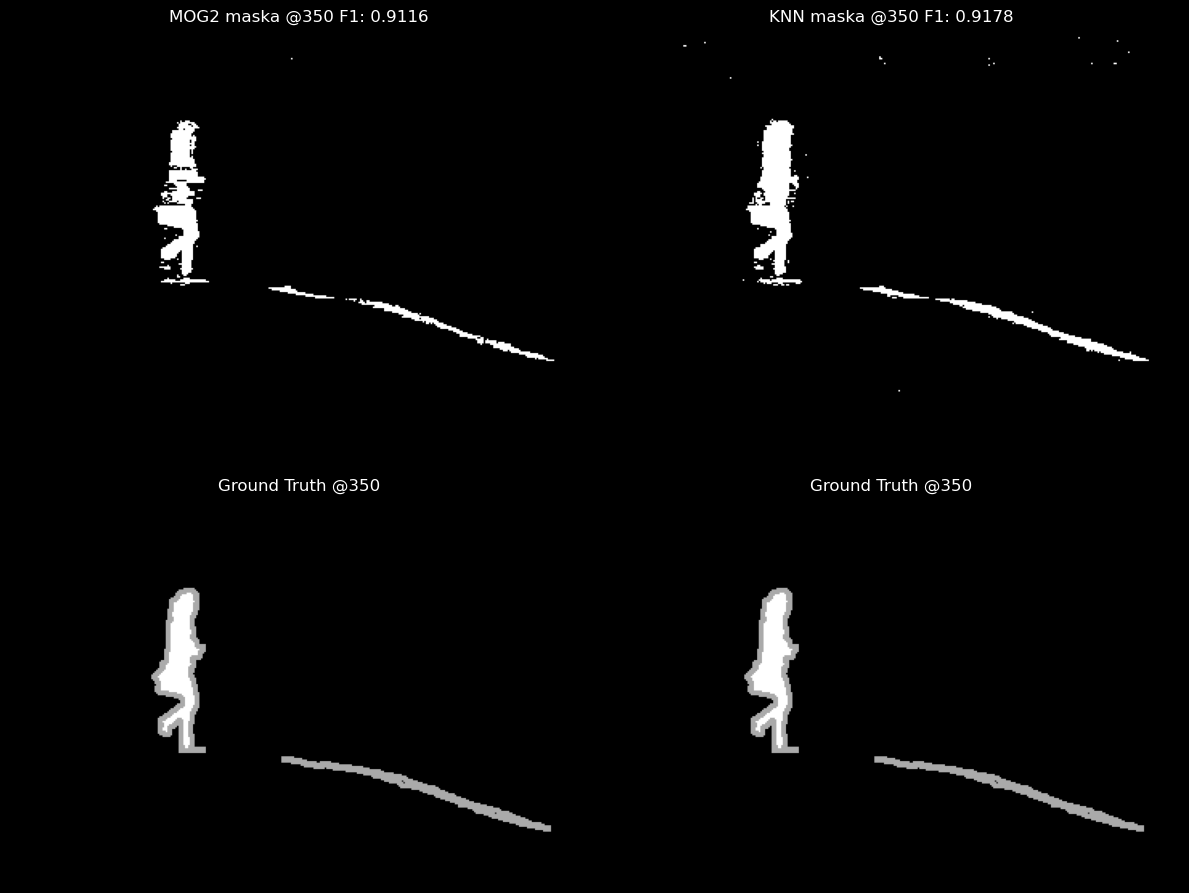

In [49]:
def bg_subtractor_eval(
    method='MOG2',
    path=pedestrian_path,
    history=200,
    var_threshold=16,
    learning_rate=-1,
    start_idx=1,
    end_idx=1000,
    sample_frame=350,
    detect_shadows=False,
 ):
    frames_dir = path / 'input'
    gt_dir = path / 'groundtruth'

    method_name = method.upper()
    if method_name == 'MOG2':
        subtractor = cv2.createBackgroundSubtractorMOG2(
            history=history,
            varThreshold=var_threshold,
            detectShadows=detect_shadows,
        )
    elif method_name == 'KNN':
        subtractor = cv2.createBackgroundSubtractorKNN(
            history=history,
            dist2Threshold=var_threshold,
            detectShadows=detect_shadows,
        )
    else:
        raise ValueError("method musi byc 'MOG2' albo 'KNN'")

    sum_f1 = 0.0
    count_valid = 0

    sample_mask = None
    sample_gt = None
    sample_f1 = None

    for i in range(start_idx, end_idx + 1):
        frame = get_frame(path=frames_dir, i=i)
        gt = get_gt(path=gt_dir, i=i)
        if frame is None or gt is None:
            break

        fg_mask = subtractor.apply(frame, learningRate=learning_rate)
        _, fg_mask_bin = cv2.threshold(fg_mask, 127, 255, cv2.THRESH_BINARY)

        metrics = evaluate_binary_mask(fg_mask_bin, gt)
        sum_f1 += metrics['f1']
        count_valid += 1

        if i == sample_frame:
            sample_mask = fg_mask_bin.copy()
            sample_gt = gt.copy()
            sample_f1 = metrics['f1']

    if count_valid == 0:
        raise RuntimeError('Nie przetworzono zadnej ramki z GT.')

    return {
        'method': method_name,
        'history': history,
        'var_threshold': var_threshold,
        'learning_rate': learning_rate,
        'frames_processed': count_valid,
        'f1_avg': sum_f1 / count_valid,
        'sample_f1': sample_f1,
        'sample_mask': sample_mask,
        'sample_gt': sample_gt,
    }

mog_result = bg_subtractor_eval(
    method='MOG2',
    path=pedestrian_path,
    history=300,
    var_threshold=75,
    learning_rate=-1,
    start_idx=1,
    end_idx=1000,
    sample_frame=350,
    detect_shadows=False,
 )

knn_result = bg_subtractor_eval(
    method='KNN',
    path=pedestrian_path,
    history=200,
    var_threshold=400,
    learning_rate=-1,
    start_idx=1,
    end_idx=1000,
    sample_frame=350,
    detect_shadows=False,
 )

def print_bg_subtractor_results(result):
    print(f"Metoda={result['method']}")
    print(f"history={result['history']}")
    print(f"threshold={result['var_threshold']}")
    print(f"learningRate={result['learning_rate']}")
    print(f"F1 avg={result['f1_avg']:.4f}")
    print(f"F1@350={result['sample_f1']:.4f}")

print_bg_subtractor_results(mog_result)
print_bg_subtractor_results(knn_result)

fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax[0][0].imshow(mog_result['sample_mask'], cmap='gray')
ax[0][0].set_title(f"{mog_result['method']} maska @350 F1: {mog_result['sample_f1']:.4f}")
ax[0][0].axis('off')
ax[1][0].imshow(mog_result['sample_gt'], cmap='gray')
ax[1][0].set_title('Ground Truth @350')
ax[1][0].axis('off')
ax[0][1].imshow(knn_result['sample_mask'], cmap='gray')
ax[0][1].set_title(f"{knn_result['method']} maska @350 F1: {knn_result['sample_f1']:.4f}")
ax[0][1].axis('off')
ax[1][1].imshow(knn_result['sample_gt'], cmap='gray')
ax[1][1].set_title('Ground Truth @350')
ax[1][1].axis('off')
plt.tight_layout()
plt.show()